# US Revascularization Rates by Age and Sex — Literature & Data Review

**Scope.** This notebook summarizes what the published literature and openly available US data say about the rates of revascularization procedures — coronary (percutaneous coronary intervention [PCI], coronary artery bypass grafting [CABG]), peripheral (lower-extremity PVI), and carotid (carotid endarterectomy [CEA], carotid artery stenting [CAS]) — stratified by age and sex, and how these rates have changed over time. See [`01_hcup_gbd_deepdive.ipynb`](01_hcup_gbd_deepdive.ipynb) for a deeper dive on AHRQ HCUP public query tools, recent-year age-specific rates, and compatibility with the GBD 2021/2023 ischemic heart disease model.

**Bottom line.**

1. Coronary revascularization rates roughly **halved** between 2003 and the mid-2010s, then plateaued. In 2016 the US adult PCI rate was ~180/100,000 and the CABG rate ~82/100,000.
2. Men receive coronary revascularization at **2.5–3× the rate** of women; the absolute gap has narrowed as overall rates declined, but the relative disparity persists.
3. Lower-extremity peripheral vascular intervention has risen and shifted strongly to **outpatient / office-based** settings; atherectomy use is growing.
4. Carotid procedures show a technology switch: **CEA declining**, **CAS rebounding sharply after 2016** (CMS coverage expansion).
5. **Neither NHANES nor NHIS core questionnaires include a self-report item for having had PCI, CABG, or stenting.** Population-level procedure rates must come from HCUP, Medicare, or commercial-claims data. BRFSS has sometimes carried procedure items in optional modules.

## 1. National coronary revascularization trends, 2003–2016

Source: Alkhouli et al., *JAMA Network Open* 2020 — analysis of the HCUP National Inpatient Sample, 12.1 million weighted hospitalizations. ([article](https://jamanetwork.com/journals/jamanetworkopen/fullarticle/2760898))

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.bbox'] = 'tight'

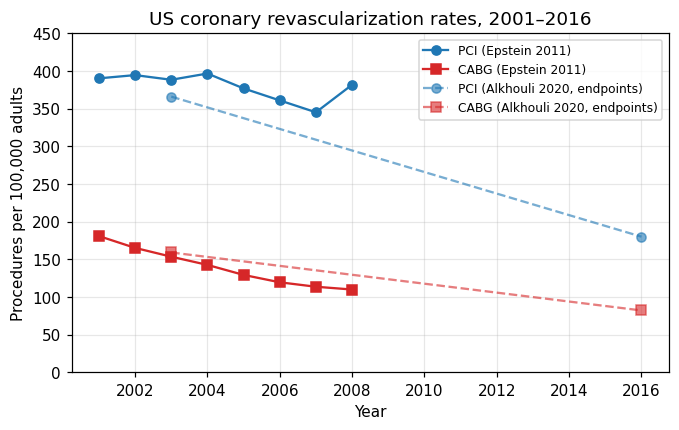

In [2]:
# Alkhouli 2020 — endpoint rates per 100,000 US adults (ages 18+) from the NIS.
# Only endpoints (2003 and 2016) are printed in the paper; we linearly interpolate
# between them for a visual reference and overlay the Epstein 2011 JAMA series
# (2001-2008), which gives a compatible picture for the overlap years.

alkhouli = pd.DataFrame({
    'year': [2003, 2016],
    'PCI_per_100k': [366, 180],
    'CABG_per_100k': [159, 82],
})

# Epstein et al., JAMA 2011 — 2001-2008, per 1,000,000 adults -> /10 for per 100,000.
epstein = pd.DataFrame({
    'year':  [2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008],
    'PCI_per_100k':  [390.3, 394.6, 388.4, 396.7, 376.9, 361.0, 345.2, 381.8],
    'CABG_per_100k': [180.8, 165.1, 153.4, 142.5, 129.2, 119.4, 113.5, 109.8],
})

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(epstein['year'], epstein['PCI_per_100k'], 'o-', color='C0', label='PCI (Epstein 2011)')
ax.plot(epstein['year'], epstein['CABG_per_100k'], 's-', color='C3', label='CABG (Epstein 2011)')
ax.plot(alkhouli['year'], alkhouli['PCI_per_100k'], 'o--', color='C0', alpha=0.6, label='PCI (Alkhouli 2020, endpoints)')
ax.plot(alkhouli['year'], alkhouli['CABG_per_100k'], 's--', color='C3', alpha=0.6, label='CABG (Alkhouli 2020, endpoints)')
ax.set_ylabel('Procedures per 100,000 adults')
ax.set_xlabel('Year')
ax.set_title('US coronary revascularization rates, 2001–2016')
ax.set_ylim(0, 450)
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()

**Reading this chart.** PCI peaked in the mid-2000s and fell by roughly half by 2016, with the sharpest drop after the 2007 COURAGE trial and subsequent appropriate-use criteria. CABG fell more steadily over the same period. Mori et al. (*JAMA Intern Med* 2019) showed that rates **stabilized** after about 2013; they have not continued to decline.

**Caveat.** The paper reports national endpoints but **does not publish rates stratified jointly by age group and sex**. To get those cuts, researchers re-analyze the NIS or use HCUPnet.

## 2. Sex-specific CABG rates among Medicare beneficiaries, 1999–2014

Source: Angraal, Khera et al., *JAHA* 2018 ([PMC6064835](https://pmc.ncbi.nlm.nih.gov/articles/PMC6064835/)). Medicare fee-for-service beneficiaries ≥65 years old; rates in procedures per 100,000 person-years.

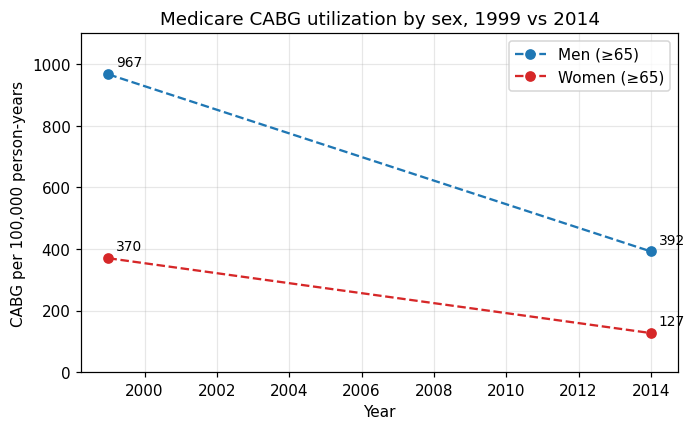

In [3]:
# Only endpoints are reported in the abstract/text; the paper shows the full trajectory
# graphically. We plot endpoints with a dashed line to signal interpolation.
medicare_cabg = pd.DataFrame({
    'year': [1999, 2014],
    'men_per_100k':   [967, 392],
    'women_per_100k': [370, 127],
})

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(medicare_cabg['year'], medicare_cabg['men_per_100k'],
        'o--', color='C0', label='Men (≥65)')
ax.plot(medicare_cabg['year'], medicare_cabg['women_per_100k'],
        'o--', color='C3', label='Women (≥65)')
for _, row in medicare_cabg.iterrows():
    ax.annotate(f"{int(row['men_per_100k'])}", (row['year'], row['men_per_100k']),
                textcoords='offset points', xytext=(5, 5), fontsize=9)
    ax.annotate(f"{int(row['women_per_100k'])}", (row['year'], row['women_per_100k']),
                textcoords='offset points', xytext=(5, 5), fontsize=9)
ax.set_ylabel('CABG per 100,000 person-years')
ax.set_xlabel('Year')
ax.set_title('Medicare CABG utilization by sex, 1999 vs 2014')
ax.set_ylim(0, 1100)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

**Key numbers (Angraal 2018).**

| Group | 1999 | 2014 | Relative decline |
|---|---|---|---|
| Men ≥65 | 967 | 392 | −59.5% |
| Women ≥65 | 370 | 127 | −65.7% |
| White | 650 | 261 | −60% |
| Black | 311 | 151 | −51% |

Men's utilization was consistently **2.5–3× women's** throughout the study period. The paper does not further disaggregate by age band within Medicare.

## 3. Sex differences in PCI volume and characteristics

Kosmidou et al. (*PLOS ONE* 2018; [article](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0203325)) analyzed 6.6 million PCI procedures in the NIS, 2004–2014:

- **~66% men, ~33% women.**
- Women were roughly **5 years older** at PCI than men (median 68 vs 63).
- Women had higher unadjusted in-hospital mortality; the gap narrowed but persisted after adjustment.

Age × sex patterns in acute MI care (Bangalore 2023, *JAHA* [article](https://www.ahajournals.org/doi/10.1161/JAHA.122.025605)) show that **women and patients ≥75** were consistently less likely to receive cardiac catheterization, PCI, or CABG during an AMI hospitalization between 2005 and 2018, with the gap **narrowing** in recent years.

## 4. Peripheral vascular intervention (PVI)

Source: Dun et al., *JAHA* 2024 ([PMC11292772](https://pmc.ncbi.nlm.nih.gov/articles/PMC11292772/)) — 599,197 Medicare PVIs for claudication, 2011–2022.

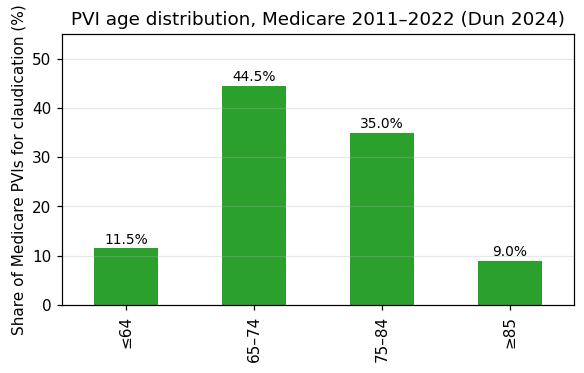

Sex distribution: 58.1% male, 41.9% female
Setting shift: office-based lab / ASC share 12.4% (2011) -> 55.7% (2022)


In [4]:
pvi_age = pd.Series(
    {'≤64': 11.5, '65–74': 44.5, '75–84': 35.0, '≥85': 9.0},
    name='% of PVIs'
)

fig, ax = plt.subplots(figsize=(6, 3.2))
pvi_age.plot(kind='bar', color='C2', ax=ax)
ax.set_ylabel('Share of Medicare PVIs for claudication (%)')
ax.set_title('PVI age distribution, Medicare 2011–2022 (Dun 2024)')
for i, v in enumerate(pvi_age.values):
    ax.text(i, v + 1, f"{v:.1f}%", ha='center', fontsize=9)
ax.set_ylim(0, 55)
ax.grid(alpha=0.3, axis='y')
plt.show()

print('Sex distribution: 58.1% male, 41.9% female')
print('Setting shift: office-based lab / ASC share 12.4% (2011) -> 55.7% (2022)')

Older literature (Jones et al., *JACC* 2015) shows the total Medicare PVI rate held roughly steady (~401 → ~420 per 100,000 beneficiaries, 2006–2011), while the setting shifted dramatically from inpatient to outpatient.

## 5. Carotid revascularization, 2006–2020

Source: Reznik et al., *Neurology* 2024 ([abstract](https://www.neurology.org/doi/10.1212/WNL.0000000000208127)) — 1,591,651 weighted procedures in the NIS.

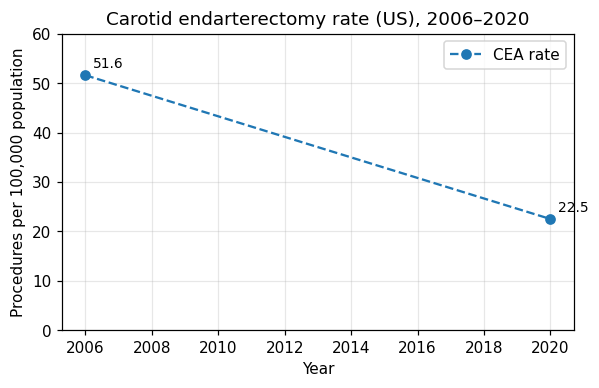

In [5]:
carotid = pd.DataFrame({
    'year': [2006, 2020],
    'CEA_per_100k': [51.6, 22.5],
    'CAS_share_%':  [np.nan, 29.6],
})

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(carotid['year'], carotid['CEA_per_100k'], 'o--', color='C0', label='CEA rate')
for _, r in carotid.iterrows():
    ax.annotate(f"{r['CEA_per_100k']:.1f}", (r['year'], r['CEA_per_100k']),
                textcoords='offset points', xytext=(5, 5), fontsize=9)
ax.set_ylabel('Procedures per 100,000 population')
ax.set_xlabel('Year')
ax.set_title('Carotid endarterectomy rate (US), 2006–2020')
ax.set_ylim(0, 60)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

- **CEA**: 51.6 → 22.5 per 100,000 (annual percentage change −5.4%).
- **CAS**: declined 2006–2016, then rose sharply (APC +16.5% men, +15.2% women, 2016–2020) after CMS expanded coverage.
- By 2020, **CAS made up ~30%** of carotid revascularizations.
- Age distribution: ~30% in 60–69-year-olds, ~20% in ≥80.

## 6. Can NHANES or NHIS answer this question?

**Short answer: no, not from core survey variables.**

### NHANES — Medical Conditions Questionnaire (MCQ) and CDQ

The Medical Conditions section ([MCQ_J 2017–2018](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/MCQ_J.htm)) collects ever-diagnosed items:

| Variable | Ever told you had... |
|---|---|
| MCQ160B | Congestive heart failure |
| MCQ160C | Coronary heart disease |
| MCQ160D | Angina / angina pectoris |
| MCQ160E | Heart attack / MI |
| MCQ160F | Stroke |

The Cardiovascular Disease Questionnaire ([CDQ_J](https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2017/DataFiles/CDQ_J.htm)) is limited to Rose angina items (chest pain quality, shortness of breath). **No item asks about having had CABG, PCI, angioplasty, or stenting.**

### NHIS — Sample Adult core

IPUMS NHIS shows the heart-condition core items are:

- `HEARTATTEV` — ever had heart attack
- `CHEARTDIEV` — ever told had coronary heart disease
- `ANGIPECEV` — ever told had angina
- `CONHFAILEV` — ever told had CHF
- `HEARTCONEV` — any other heart condition

Procedure history has shown up only in **topical supplements** in selected years (e.g., the 2004/2007 Heart Disease and Stroke supplement, Cancer Control Supplement) — not in the standing core.

### What to use instead

For population rates of revascularization in the US, go to discharge and claims data:

| Source | Coverage | Free access |
|---|---|---|
| **HCUPnet** (AHRQ) | NIS/NEDS/KID 1993+; national rates by age/sex/payer | [datatools.ahrq.gov/hcupnet](https://datatools.ahrq.gov/hcupnet/) |
| **HCUP Statistical Briefs** | Topic-specific PDFs on OR procedures | [hcup-us.ahrq.gov/reports/statbriefs](https://hcup-us.ahrq.gov/reports/statbriefs/) |
| **CMS Medicare Part B procedure volumes** | HCPCS-level annual counts | [data.cms.gov](https://data.cms.gov) |
| **CDC Heart Disease & Stroke Atlas** | County-level Medicare FFS | [cdc.gov/heart-disease-stroke-atlas](https://www.cdc.gov/heart-disease-stroke-atlas/) |
| **State agencies** (e.g., California HCAI) | State-level, often public | [hcai.ca.gov](https://hcai.ca.gov/visualizations/trends-in-the-utilization-and-mortality-for-cabg-surgery/) |
| **CDC WONDER** | Mortality only — not procedures | [wonder.cdc.gov](https://wonder.cdc.gov) |

## 7. Summary

- **US coronary revascularization** rates roughly halved between the mid-2000s and 2016 (PCI 366 → 180/100,000; CABG 159 → 82/100,000) and have since plateaued.
- **Sex**: Men's CABG rate is about **3×** women's in Medicare; men account for ~**66%** of PCIs.
- **Age**: Revascularization concentrates in **65–84-year-olds**; use among **≥85** has grown slowly but is still small.
- **Peripheral**: Medicare PVI for claudication has shifted to outpatient settings; women are ~42% of cases.
- **Carotid**: CEA is declining; CAS has rebounded since CMS coverage expansion in 2016.
- **NHANES / NHIS**: Neither core survey asks about having had CABG, PCI, or stent placement. National estimates require HCUP, Medicare, or private-claims data.

### Selected references

1. Alkhouli M, et al. Trends in coronary revascularization outcomes in the US, 2003–2016. *JAMA Netw Open* 2020. [link](https://jamanetwork.com/journals/jamanetworkopen/fullarticle/2760898)
2. Epstein AJ, et al. Coronary revascularization trends in the US, 2001–2008. *JAMA* 2011. [PMC3164857](https://pmc.ncbi.nlm.nih.gov/articles/PMC3164857/)
3. Angraal S, Khera R, et al. Sex and race differences in Medicare CABG, 1999–2014. *JAHA* 2018. [PMC6064835](https://pmc.ncbi.nlm.nih.gov/articles/PMC6064835/)
4. Kosmidou I, et al. Persistent sex disparities in PCI outcomes — 6.6 million procedures. *PLOS ONE* 2018. [link](https://journals.plos.org/plosone/article?id=10.1371/journal.pone.0203325)
5. Mori M, et al. Stability in coronary revascularization rates. *JAMA Intern Med* 2019. [PubMed 31039350](https://pubmed.ncbi.nlm.nih.gov/31039350/)
6. Khera R, et al. Age and sex differences in invasive cardiac procedures for AMI, 2005–2018. *JAHA* 2023. [link](https://www.ahajournals.org/doi/10.1161/JAHA.122.025605)
7. Dun C, et al. Trends in PVI for claudication, Medicare 2011–2022. *JAHA* 2024. [PMC11292772](https://pmc.ncbi.nlm.nih.gov/articles/PMC11292772/)
8. Reznik M, et al. 15-year trends in carotid revascularization by age and sex. *Neurology* 2024. [link](https://www.neurology.org/doi/10.1212/WNL.0000000000208127)
9. Jones WS, et al. Settings for peripheral vascular intervention. *JACC* 2015. [PubMed 25744009](https://pubmed.ncbi.nlm.nih.gov/25744009/)
10. SCAI Expert Consensus on Sex-Specific Considerations in Myocardial Revascularization, 2022. [link](https://www.jscai.org/article/S2772-9303(21)00016-8/fulltext)